In [1]:
import sys
sys.path.insert(0, "..")

import joblib

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from loguru import logger

pd.set_option("display.max_columns", None)

In [2]:
from src.evaluation.metrics import build_predictions_report

In [4]:
LEVEL = 'level_09_daily_store_dept'

In [5]:
import joblib

artifact_path = f"../artifacts/{LEVEL}_artifact.pkl"
artifact = joblib.load(artifact_path)

# Desempaquetar lo que necesites
model = artifact["model"]
X_test, y_test = artifact["X_test"], artifact["y_test"]
FEATURES = artifact["features"]
feature_importance = artifact["feature_importance"]
results_df = artifact["results_df"]

## Explicación modelo

In [6]:
import shap

explainer = shap.TreeExplainer(model)

X_shap = X_test.sample(n=min(2000, len(X_test)), random_state=42)
shap_values = explainer.shap_values(X_shap)

In [7]:
shap_df = pd.DataFrame(shap_values, columns=X_shap.columns, index=X_shap.index)

importance_df = pd.DataFrame({
    "feature": X_shap.columns,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0),
}).sort_values("mean_abs_shap", ascending=False)

print(importance_df)

                                              feature  mean_abs_shap
10                                               lag1     162.156069
12                                               lag7     113.806629
15                                              lag28      49.184997
6                                           dayofweek      23.785621
11                                               lag2      20.921715
4                                                snap      20.557476
18                    rolling_mean_lag7_window_size14      19.405090
21                    rolling_mean_lag28_window_size7      17.224187
16                     rolling_mean_lag7_window_size7      16.065448
14                                              lag21      12.369517
0                                             dept_id      10.986671
7                                        price_vs_max       9.305901
13                                              lag14       9.207506
3                                 

### Importancia global de features

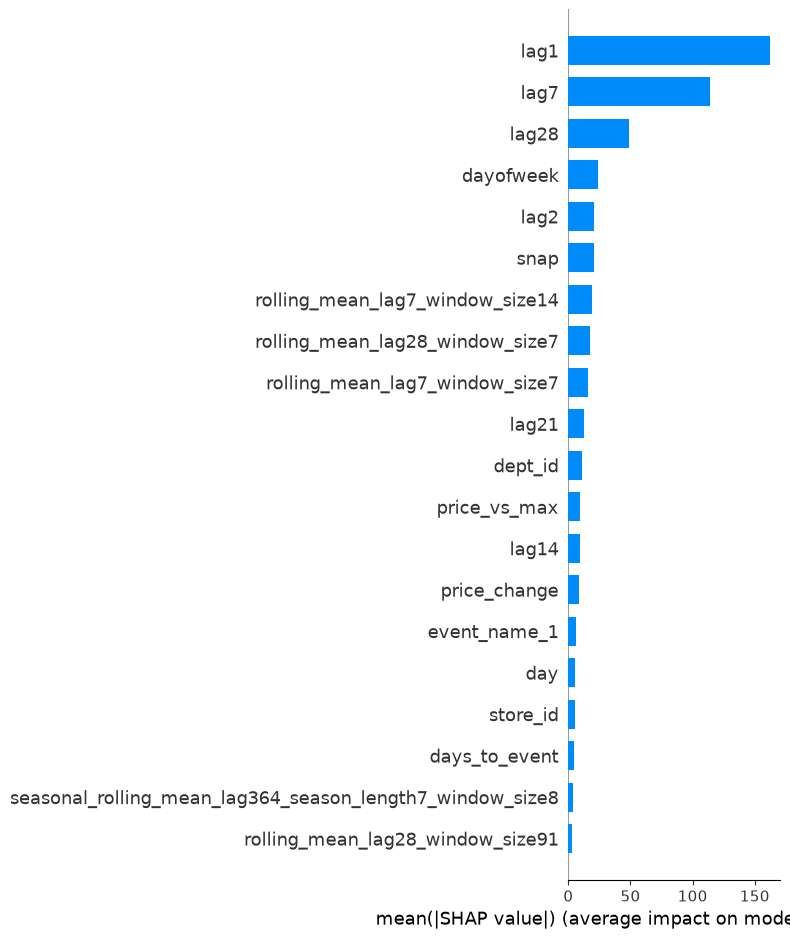

In [8]:
shap.summary_plot(shap_values, X_shap, plot_type="bar")

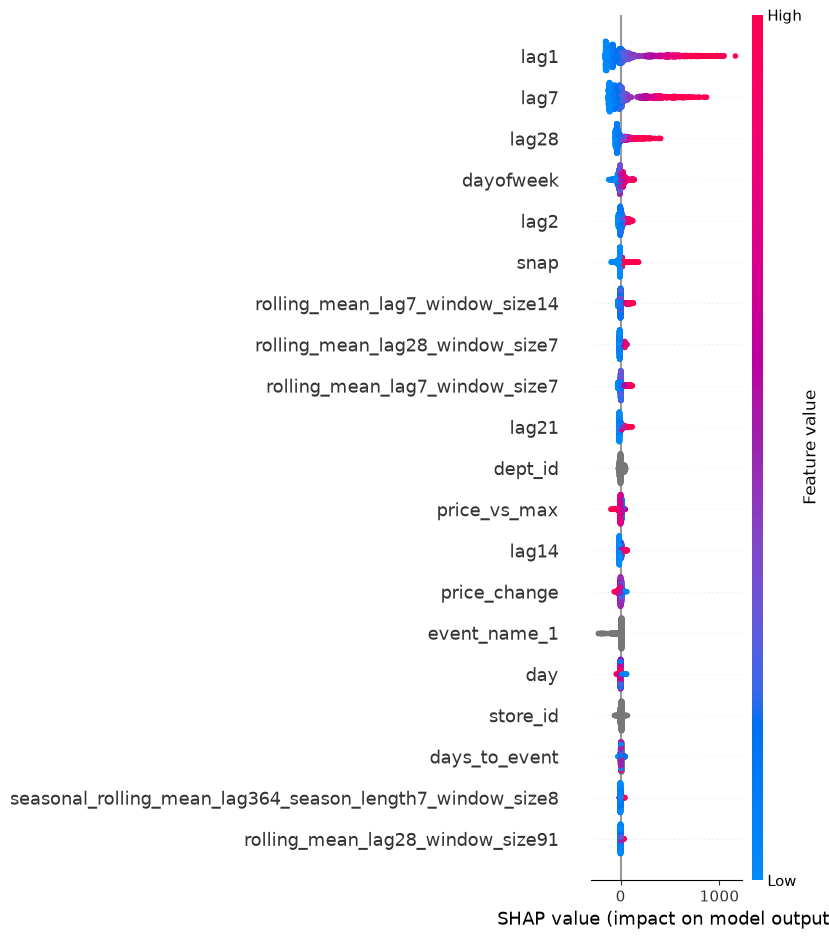

In [9]:
shap.summary_plot(shap_values, X_shap)

### Dependencia por feature

Feature más importante: lag1


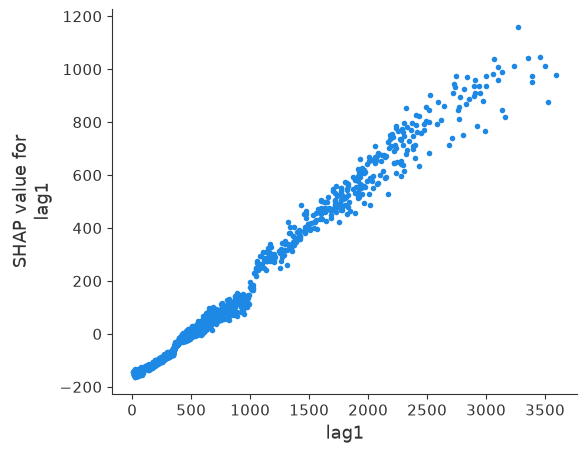

In [10]:
top_feature = X_shap.columns[np.argsort(-np.abs(shap_values).mean(axis=0))[0]]
print(f"Feature más importante: {top_feature}")

shap.dependence_plot(top_feature, shap_values, X_shap, interaction_index=None)

In [11]:
metrics_test_final, df_pred = build_predictions_report(artifact['train'], artifact['test'], y_test, model.predict(X_test), target_col=artifact['target'])

print(f"Test WAPE: {metrics_test_final['wape']:.2%}")
print(f"Test WRMSSE: {metrics_test_final['wrmsse']:.4f}")

Test WAPE: 8.67%
Test WRMSSE: 0.6154


# Predicciones

In [36]:
from src.evaluation import analizar_prediccion as _analizar_prediccion

def analizar_prediccion(agg_id, test=artifact['test'], target=artifact['target'],
                         explainer=explainer, date=None, max_display=10):
    return _analizar_prediccion(
        test, X_test, df_pred, target, agg_id,
        date=date, max_display=max_display, explainer=explainer,
    )

In [ ]:
from src.evaluation.metrics import build_series_metrics

df_metrics = build_series_metrics(artifact['train'], df_pred, target_col=artifact['target'], weight_level=["date"])
df_metrics.head(10)

,sales,gross_sales,gross_sales_pct,wape,bias,rmsle,tracking_signal,wrmsse,mase,spec
agg_id,,,,,,,,,,
FOODS_3_FOODS_CA_3_CA,80752.0,203732.281250,0.050132,0.067070,0.013919,0.078912,-6.018464,0.472257,0.500765,270.146552
FOODS_3_FOODS_CA_1_CA,68989.0,175612.812500,0.043213,0.044181,-0.034846,0.057329,22.872703,0.358326,0.287494,851.353448
HOUSEHOLD_1_HOUSEHOLD_CA_3_CA,40366.0,171702.140625,0.042251,0.051058,0.016227,0.072221,-9.216400,0.433621,0.462022,56.232759
FOODS_3_FOODS_WI_2_WI,70371.0,160068.843750,0.039388,0.080587,-0.028662,0.093976,10.314407,0.762179,0.687426,891.775862
FOODS_3_FOODS_CA_2_CA,59842.0,153737.015625,0.037830,0.078005,-0.041944,0.091986,15.593402,0.761536,0.761406,734.482759
...,...,...,...,...,...,...,...,...,...,...
HOBBIES_2_HOBBIES_TX_1_TX,1265.0,2655.500000,0.000653,0.258498,-0.106719,0.314268,11.972477,1.378895,1.365861,49.043103
HOBBIES_2_HOBBIES_WI_1_WI,1152.0,2380.040039,0.000586,0.250868,-0.059896,0.361328,6.923875,1.033569,1.032482,60.310345
HOBBIES_2_HOBBIES_WI_2_WI,1044.0,2115.219971,0.000520,0.265326,-0.045019,0.325375,4.920578,1.428570,1.141099,37.034483


In [ ]:
df_metrics.head(10)

In [38]:
df_pred.query('agg_id == "FOODS_3_FOODS_CA_3_CA"').nlargest(10, 'wape')

,agg_id,date,sales,gross_sales,y_pred,error,abs_error,wape,bias
44635,FOODS_3_FOODS_CA_3_CA,2016-05-15,3496.0,8896.730469,2994.0,502.0,502.0,0.143593,-0.143593
44615,FOODS_3_FOODS_CA_3_CA,2016-04-25,2972.0,7675.609863,2574.0,398.0,398.0,0.133917,-0.133917
44632,FOODS_3_FOODS_CA_3_CA,2016-05-12,2202.0,5538.709961,2487.0,-285.0,285.0,0.129428,0.129428
44623,FOODS_3_FOODS_CA_3_CA,2016-05-03,2655.0,6551.040039,2996.0,-341.0,341.0,0.128437,0.128437
44616,FOODS_3_FOODS_CA_3_CA,2016-04-26,2240.0,5626.109863,2523.0,-283.0,283.0,0.126339,0.126339
44636,FOODS_3_FOODS_CA_3_CA,2016-05-16,2615.0,6564.209961,2923.0,-308.0,308.0,0.117782,0.117782
44642,FOODS_3_FOODS_CA_3_CA,2016-05-22,3573.0,8930.370117,3163.0,410.0,410.0,0.114750,-0.114750
44627,FOODS_3_FOODS_CA_3_CA,2016-05-07,3135.0,7922.120117,3461.0,-326.0,326.0,0.103987,0.103987
44618,FOODS_3_FOODS_CA_3_CA,2016-04-28,2209.0,5390.859863,2435.0,-226.0,226.0,0.102309,0.102309
44629,FOODS_3_FOODS_CA_3_CA,2016-05-09,3238.0,8316.910156,2945.0,293.0,293.0,0.090488,-0.090488


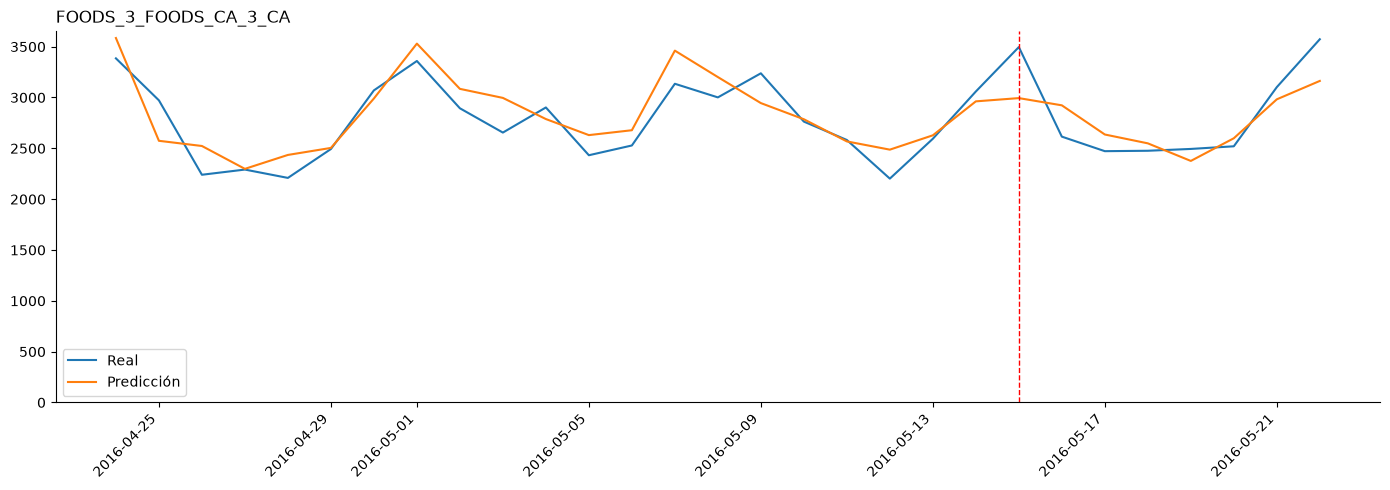

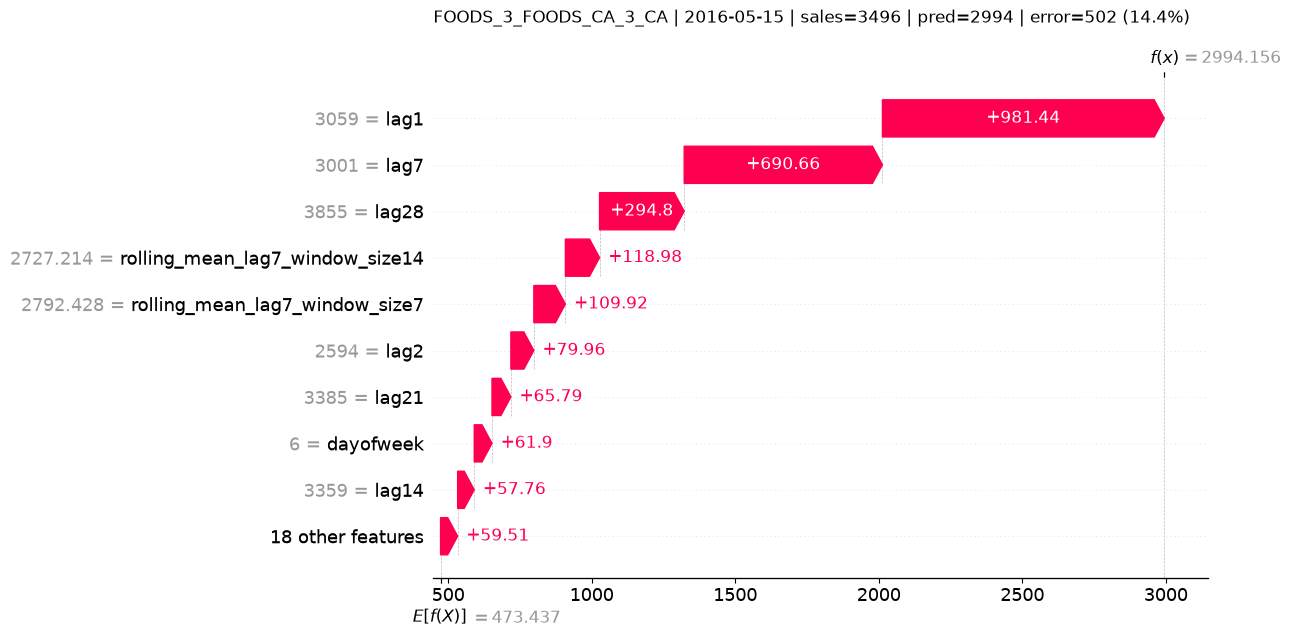

In [39]:
analizar_prediccion(agg_id='FOODS_3_FOODS_CA_3_CA', date='2016-05-15' )